In [21]:
import numpy as np
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

scores = np.load("../results/anomaly_scores.npy")
y_true = np.load("../results/ground_truth.npy")

print("Scores shape:", scores.shape)
print("Labels shape:", y_true.shape)


Scores shape: (2010,)
Labels shape: (2010,)


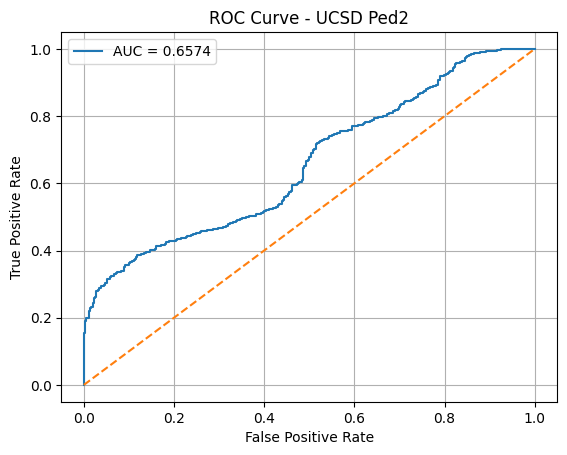

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - UCSD Ped2")
plt.legend()
plt.grid()
plt.show()


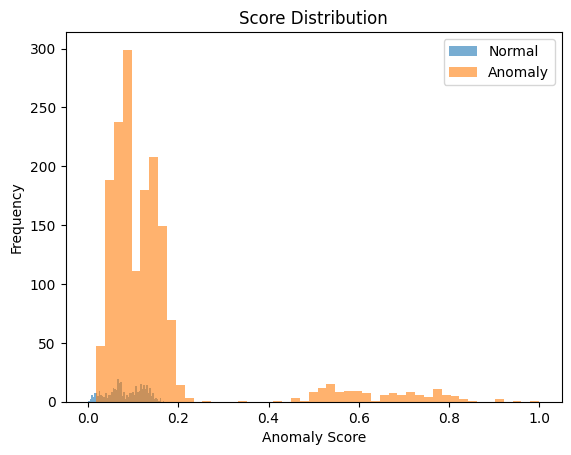

In [23]:
normal_scores = scores[y_true == 0]
anomaly_scores = scores[y_true == 1]

plt.figure()
plt.hist(normal_scores, bins=50, alpha=0.6, label="Normal")
plt.hist(anomaly_scores, bins=50, alpha=0.6, label="Anomaly")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title("Score Distribution")
plt.legend()
plt.show()


In [28]:
import os
import glob
from preprocessing.load_datasets import load_ucsd_ped2

# Get project root and load test videos
cwd = os.getcwd()
project_root = cwd if os.path.exists(os.path.join(cwd, "data")) else os.path.dirname(cwd)
data_root = os.path.join(project_root, "data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2")

_, all_test_videos = load_ucsd_ped2(data_root)

# Filter to only videos with ground truth
gt_path = os.path.join(data_root, "UCSDped2/Test")
gt_folders = set([f.replace("_gt", "") for f in os.listdir(gt_path) if f.endswith("_gt")])
test_videos = sorted([v for v in all_test_videos if os.path.basename(v) in gt_folders])

print(f"Loaded {len(test_videos)} test videos with ground truth")

Loaded 12 test videos with ground truth


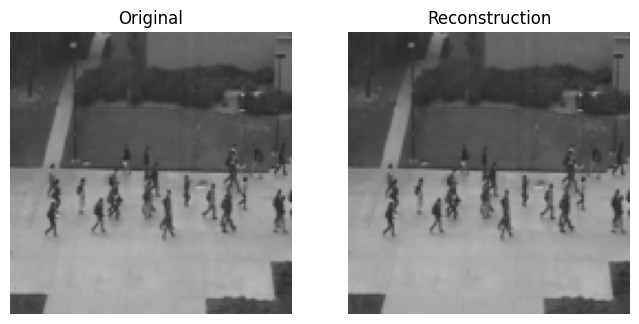

In [29]:
import torch
import matplotlib.pyplot as plt
from preprocessing.video_dataset import VideoFrameDataset
from preprocessing.transforms import get_transform
from models.conv_autoencoder import ConvAutoencoder

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ConvAutoencoder().to(device)
model.load_state_dict(torch.load("../checkpoints/conv_autoencoder.pth", map_location=device))
model.eval()

dataset = VideoFrameDataset(test_videos, transform=get_transform(128))

frame = dataset[0].unsqueeze(0).to(device)

with torch.no_grad():
    recon = model(frame)

orig = frame.squeeze().cpu().permute(1, 2, 0)
reco = recon.squeeze().cpu().permute(1, 2, 0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reco)
plt.title("Reconstruction")
plt.axis("off")
plt.show()
